In [1]:
import numpy as np
import serial
import time
import matplotlib.pyplot as plt
from IPython import display
import concurrent.futures
import serial.tools.list_ports
ports = serial.tools.list_ports.comports()
[x[0] for x in ports if "CH9102" in ports[0][1]]

['COM4', 'COM6']

In [2]:
def ser_readline(ser: serial.Serial, timeout = .5, get_all_lines = False):
    t0 = time.perf_counter()
    _str = ''
    bad_counter = 0
    lines = []
    while time.perf_counter() - t0 < timeout:
        if ser.in_waiting == 0:
            time.sleep(.1)
            continue
        c = ser.read()
        if (c == bytes([0])) or (c > bytes([127])):
            bad_counter += 1
            continue

        _str += c.decode()
        if (c == b"\n") or (c == b"\r"):
            _line = _str
            _str = ''
            if get_all_lines:
                t0 = time.perf_counter()
                lines.append(_line)
            else:
                return [_line]
        if bad_counter > 50:
            print("hex")
            break
    return lines


def parse_data(ret1:str)->np.ndarray:
    data = [[], [], [], [], [], []]
    for _l in ret1:
        if not _l.startswith("T:"): continue
        _s = _l.split(',')
        if len(_s) != 6: continue
        for n in range(6):
            _s2 = _s[n].split(':')
            if len(_s2) != 2: continue
            if _s2[0] == ["T", "F", "S", "R", "Sun", "L"][n]: data[n].append(float(_s2[1]))
    return np.array(data)

#helper functions
# convert protocol to ambit array
def gen_cmd_arr_line(num:int, freq:int, actinic:int)->list:
    return [2, 0, num//256, num%256, freq//256, freq%256, actinic, 1]


# flatten ambit array, calc time, actinic array
def calc_arr_param(cmd: list, persist:bool = False):
    cmd_arr = np.reshape(cmd, (-1, 8))
    arr_length = cmd_arr.shape[0]
    cmd_str = "arrun1," + str(arr_length) + "," + str(persist) + ","+ str(cmd)[1:-1] + ",\n"
    cmd_str = cmd_str.replace(" ", "")

    num_pts = cmd_arr[:, 2] * 256 + cmd_arr[:, 3]
    act_arr = cmd_arr[:, 6]
    mea_feq = 1 / (cmd_arr[:, 4] * 256 + cmd_arr[:, 5])
    _t, mea_tml, mea_act = 0, [], []
    for _n, _f, _a in zip(num_pts, mea_feq, act_arr):
        mea_tml += (np.arange(_n) * _f + _t).tolist()
        mea_act += [_a] * _n
        _t = mea_tml[-1]
    mea_tml = np.array(mea_tml) * 0.854
    return cmd_str, mea_tml, mea_act

In [3]:
def cmd2(cmd:str, ser1: serial.Serial, ser2: serial.Serial, timeout = .5, get_all_lines = False)-> (str, str):    
    with concurrent.futures.ThreadPoolExecutor(max_workers=2) as executor:
        ser1.write((cmd+'\n\r').encode())
        ser2.write((cmd+'\n\r').encode())
        f1 = executor.submit(ser_readline, ser1, timeout, get_all_lines)
        f2 = executor.submit(ser_readline, ser2, timeout, get_all_lines)
        result1 = f1.result()
        result2 = f2.result()
        return result1, result2

Text(0.5, 1.0, 'Protocol preview')

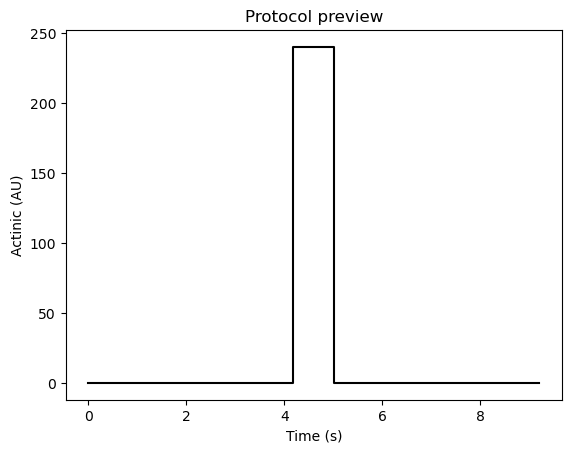

In [7]:
# create a trace with 3 different setups:
# 1. 50 points, 10Hz, no actinic
# 2. 50 points, 50Hz, 240/255(max) actinic
# 3. 50 points, 10Hz, no actinic
# number of lines (1 - 8) points(10 - 2000), freq (1 - 200), actinic 0 - 255

cmd = []
cmd += gen_cmd_arr_line(num = 50, freq = 10, actinic = 0)
cmd += gen_cmd_arr_line(num = 50, freq = 50, actinic = 240)
cmd += gen_cmd_arr_line(num = 50, freq = 10, actinic = 0)


# convert to command for ambit, also pre-calculate the time and actinic of each point
cmd_str, timeline, act_arr = calc_arr_param(cmd, 0)
plt.plot(timeline, act_arr, 'k')
plt.xlabel("Time (s)")
plt.ylabel("Actinic (AU)")
plt.title("Protocol preview")

In [5]:
with serial.Serial("COM4", baudrate=115200) as ser1:
    with serial.Serial("COM6", baudrate=115200) as ser2:
        ret1, ret2 = cmd2(cmd_str, ser1, ser2, 1, True)

data = [parse_data(ret1), parse_data(ret2)]

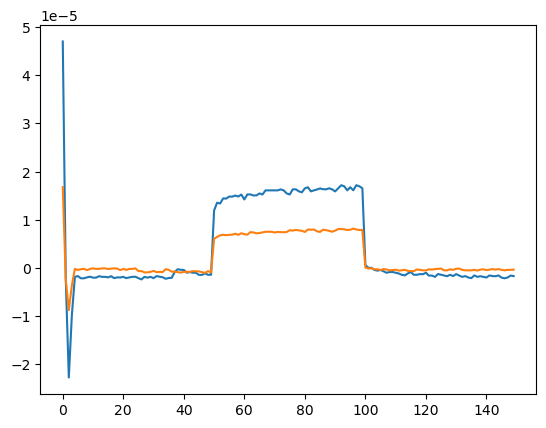

In [6]:
for d in data:
    fluo = d[1, :] / d[2, :]
    fluo_off = fluo - fluo[:10].mean()
    plt.plot(fluo_off)
